## Dataset Overview

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
import joblib

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.1)

# Paths
CHEATER_PATH = "../data/full_dataset/with_cheater_present"
NON_CHEATER_PATH = "../data/context_windows_512/not_cheater"
RESULTS_PATH = "../results"
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR = os.path.join(BASE_DIR, "results")

rf_path = os.path.join(RESULTS_DIR, "random_forest_model.pkl")
lr_path = os.path.join(RESULTS_DIR, "logistic_regression_model.pkl")
X_test_path = os.path.join(RESULTS_DIR, "X_test.csv")
y_test_path = os.path.join(RESULTS_DIR, "y_test.csv")


## Load Sample Data

In [2]:
def load_sample_data(n_files=50, rows_per_file=50000):
    cheater_files = [os.path.join(CHEATER_PATH, f) for f in os.listdir(CHEATER_PATH) if f.endswith(".parquet")][:n_files]
    non_cheater_files = [os.path.join(NON_CHEATER_PATH, f) for f in os.listdir(NON_CHEATER_PATH) if f.endswith(".parquet")][:n_files]

    dfs = []
    for path, label in [(cheater_files, 1), (non_cheater_files, 0)]:
        for f in path:
            try:
                table = pq.read_table(f)
                df = table.to_pandas().head(rows_per_file)
                df["is_cheater"] = label
                dfs.append(df)
            except Exception as e:
                print(f"Skipped {f} due to error: {e}")
    df = pd.concat(dfs, ignore_index=True)
    return df

df = load_sample_data(n_files=50, rows_per_file=50000)
print(f"Loaded dataset shape: {df.shape}")
df.head()

: 

## Data Visualizations

### Balancing Plot

/var/folders/0h/mcgbb4750lsc9nt42mnstlqw0000gn/T/ipykernel_85399/1550214060.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


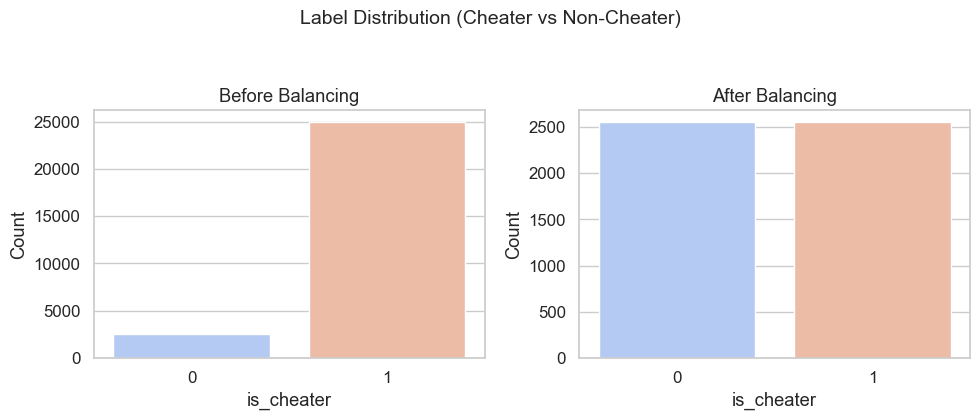

In [55]:
# Balancing dataset
df_before = df.copy()
min_count = df["is_cheater"].value_counts().min()
df = (
    df.groupby("is_cheater", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)
df_after = df.copy()

import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(ax=axes[0], x="is_cheater", data=df_before, palette="coolwarm", hue="is_cheater", legend=False)
axes[0].set_title("Before Balancing")
axes[0].set_xlabel("is_cheater")
axes[0].set_ylabel("Count")

sns.countplot(ax=axes[1], x="is_cheater", data=df_after, palette="coolwarm", hue="is_cheater", legend=False)
axes[1].set_title("After Balancing")
axes[1].set_xlabel("is_cheater")
axes[1].set_ylabel("Count")

plt.suptitle("Label Distribution (Cheater vs Non-Cheater)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Histogram

<Figure size 1200x500 with 0 Axes>

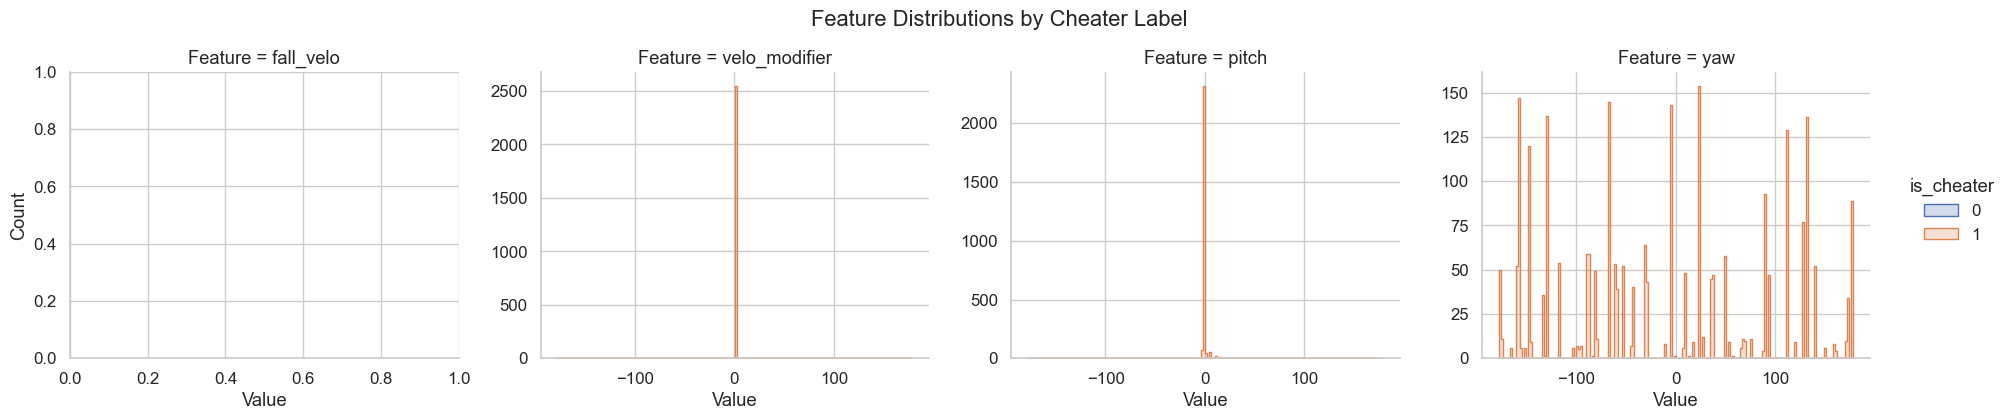

In [56]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_subset = [col for col in num_cols if any(k in col.lower() for k in ["yaw", "pitch", "vel"])]
df_melt = df.melt(value_vars=feature_subset[:4], 
                  id_vars="is_cheater", 
                  var_name="Feature", 
                  value_name="Value")

plt.figure(figsize=(12,5))
sns.displot(
    df_melt,
    x="Value",
    hue="is_cheater",
    col="Feature",
    kind="hist",
    element="step",
    multiple="layer",
    common_norm=False,
    facet_kws={"sharex": False, "sharey": False},
    height=4,
    aspect=1.2
)
plt.suptitle("Feature Distributions by Cheater Label", y=1.05)
plt.show()


### Necessary Paths and Predictions

In [57]:
# Paths
rf_path = os.path.join(RESULTS_PATH, "random_forest_model.pkl")
lr_path = os.path.join(RESULTS_PATH, "logistic_regression_model.pkl")
X_test_path = os.path.join(RESULTS_PATH, "X_test.csv")
y_test_path = os.path.join(RESULTS_PATH, "y_test.csv")

rf = joblib.load(rf_path)
lr = joblib.load(lr_path)
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).squeeze()

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_lr = lr.predict_proba(X_test)[:, 1]

/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packa

### Confusion Matrix

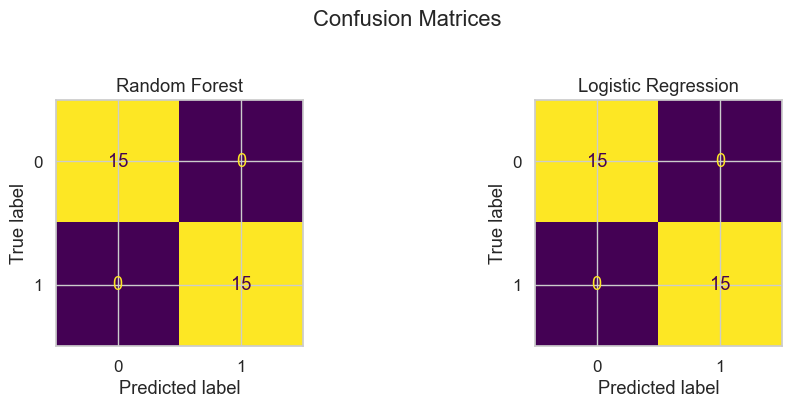

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Random Forest")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Logistic Regression")
plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

### Summary Plot

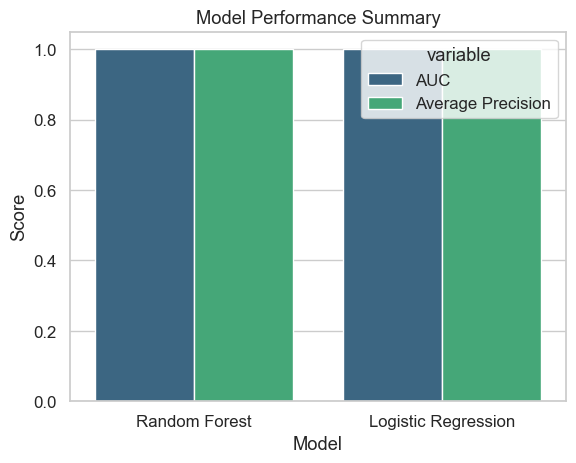

In [59]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ap_rf = average_precision_score(y_test, y_prob_rf)
ap_lr = average_precision_score(y_test, y_prob_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)
summary = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "AUC": [auc_rf, auc_lr],
    "Average Precision": [ap_rf, ap_lr]
})

sns.barplot(data=summary.melt(id_vars="Model"), 
            x="Model", 
            y="value", 
            hue="variable", 
            palette="viridis")
plt.title("Model Performance Summary")
plt.ylabel("Score")
plt.show()

### Feature Importance - Random Forest

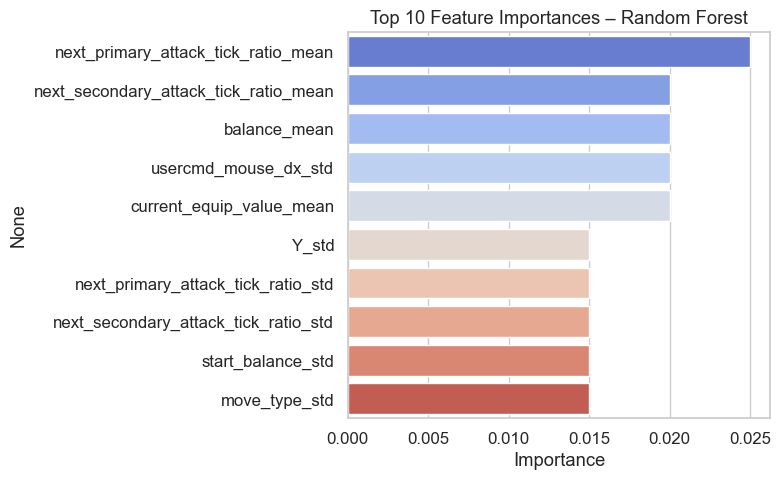

In [60]:
if hasattr(rf, "feature_importances_"):
    importances = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.head(10), 
                y=importances.head(10).index, 
                palette="coolwarm", 
                hue = importances.head(10).index, 
                legend = False)
    plt.title("Top 10 Feature Importances – Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()